# Prepare data


In [ ]:
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from google.colab import auth
from google.cloud import bigquery, storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Authenticate and set up environment
auth.authenticate_user()
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
!gcloud config set project {project_id}

# Initialize BigQuery client
client = bigquery.Client(project=project_id)

# Initialize GCP Storage client with user_project parameter
storage_client = storage.Client(project=project_id)
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name, user_project=project_id)

# Path to the filtered combined data CSV in your GCP bucket
filtered_data_path = 'final_combined_data.csv'
filtered_blob = bucket.blob(filtered_data_path)

# Download the filtered combined data CSV to a local temporary file
local_filtered_data_path = '/tmp/final_combined_data.csv'
filtered_blob.download_to_filename(local_filtered_data_path)

# Load the filtered combined data CSV into a DataFrame
df = pd.read_csv(local_filtered_data_path)


# Extract embedding vectors
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
print (embeddings)
avg_peep = df['avg_peep']
print(avg_peep)

Updated property [core/project].
      embedding_0  embedding_1  embedding_2  embedding_3  embedding_4  \
0       -1.740258    -0.782546     0.805217    -1.685203    -0.150928   
1       -0.911495    -0.515437     0.619245    -2.373145    -0.171805   
2       -1.034045    -0.783105     0.583782    -1.079196     0.196727   
3       -1.498975    -0.566318     0.506368    -1.586067     0.069659   
4       -0.716697    -0.587135     1.320426    -2.036464    -0.071745   
...           ...          ...          ...          ...          ...   
1112    -1.295518    -0.371794     0.170809    -2.018295     0.624668   
1113    -0.767546    -0.130139     0.142088    -2.607982    -0.953248   
1114    -0.091549    -1.316677     0.362403    -2.207046     0.192631   
1115     0.394565    -0.205986     1.213435    -1.648330     0.394253   
1116    -0.996493    -1.363348     0.844462    -1.462523     0.076252   

      embedding_5  embedding_6  embedding_7  embedding_8  embedding_9  ...  \
0        0.5

# Not working: PEEP and CXR as an input to predict/alter mortality

Test ROC-AUC: 0.6352272727272728
Optimal PEEP: 5.0, Predicted Mortality Probability: 0.06390206683344045


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid

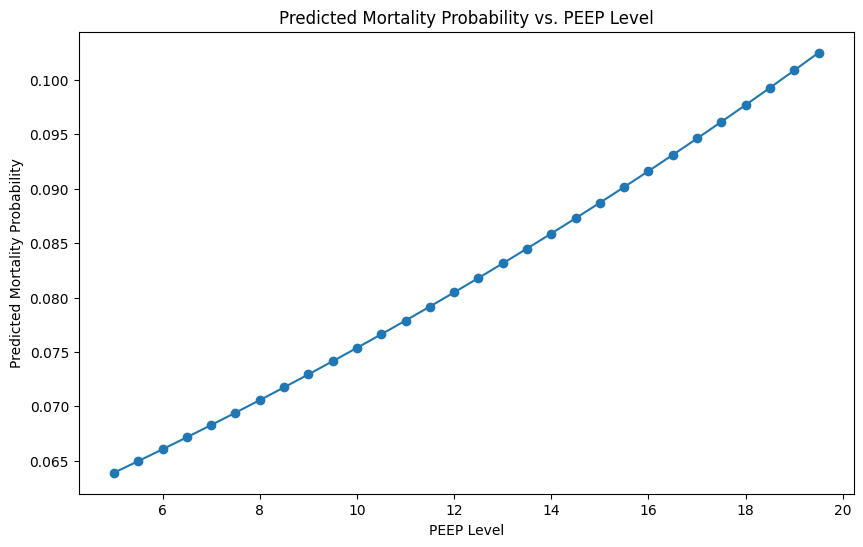

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Assuming your dataset includes the following columns:
# 'embedding_1', 'embedding_2', ..., 'embedding_n' for CXR embeddings
# 'avg_peep' for average PEEP levels
# 'icu_mort' for mortality information

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
avg_peep = df['avg_peep']
mortality = df['icu_mort']

# Standardize the data
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

# Apply PCA
pca = PCA(n_components=100)
embeddings_pca = pca.fit_transform(embeddings_scaled)

# Combine PCA components and avg_peep levels for training
data_pca = pd.DataFrame(embeddings_pca, columns=[f'pca_{i+1}' for i in range(embeddings_pca.shape[1])])
data_pca['avg_peep'] = avg_peep.values
X = data_pca
y = mortality

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict mortality probability on the test set
y_test_prob = model.predict_proba(X_test)[:, 1]

# Evaluate the model
test_roc_auc = roc_auc_score(y_test, y_test_prob)
print(f"Test ROC-AUC: {test_roc_auc}")

# Function to optimize PEEP levels for minimizing mortality probability
def optimize_peep(embeddings_pca, current_peep, model, step=0.5, range_min=5, range_max=20):
    best_peep = current_peep
    best_prob = 1.0

    for peep in np.arange(range_min, range_max, step):
        temp_data = np.hstack((embeddings_pca.reshape(1, -1), np.array([[peep]])))
        temp_prob = model.predict_proba(temp_data)[:, 1][0]
        if temp_prob < best_prob:
            best_prob = temp_prob
            best_peep = peep

    return best_peep, best_prob

# Example usage with a single patient's data
patient_index = 0  # Index of the patient in the test set
patient_embeddings_pca = X_test.iloc[patient_index, :-1].values  # Exclude current avg_peep
current_peep = X_test.iloc[patient_index, -1]

optimal_peep, predicted_mortality = optimize_peep(patient_embeddings_pca, current_peep, model)
print(f"Optimal PEEP: {optimal_peep}, Predicted Mortality Probability: {predicted_mortality}")

# Visualize the predicted mortality probabilities for different PEEP levels
peep_levels = np.arange(5, 20, 0.5)
probabilities = []

for peep in peep_levels:
    temp_data = np.hstack((patient_embeddings_pca.reshape(1, -1), np.array([[peep]])))
    temp_prob = model.predict_proba(temp_data)[:, 1][0]
    probabilities.append(temp_prob)

plt.figure(figsize=(10, 6))
plt.plot(peep_levels, probabilities, marker='o')
plt.xlabel('PEEP Level')
plt.ylabel('Predicted Mortality Probability')
plt.title('Predicted Mortality Probability vs. PEEP Level')
plt.show()


          pca_1      pca_2      pca_3      pca_4      pca_5      pca_6  \
0     -7.824472  -6.628519  -5.744005   4.293053   1.582232  -4.043830   
1     -5.618740  -3.196860   2.356425  -0.994804   1.820275  -2.295385   
2    -10.480076  -1.080030  -0.747492  -5.639868   4.389773  -0.267324   
3    -12.105477   0.234711  -8.078770  -6.243325  13.117540  -3.162780   
4    -12.048912 -12.360408   0.844212  14.270819  10.235923   5.405155   
...         ...        ...        ...        ...        ...        ...   
1112  -5.955091   2.549122  10.098725   9.548938   2.098757  -2.074380   
1113 -20.695156  -9.324525  -6.862463  -5.873841  -0.116551  11.023663   
1114  -3.783816  -8.733032 -10.531540  -3.796672 -22.246497  -6.412112   
1115  18.521546  11.922847   9.426888  39.420639  -7.843864  16.879252   
1116 -13.989403  -6.749390  -6.580039  -1.347090   2.624740   8.066596   

          pca_7      pca_8      pca_9     pca_10  ...    pca_42    pca_43  \
0     17.652603   3.754995  -6.484

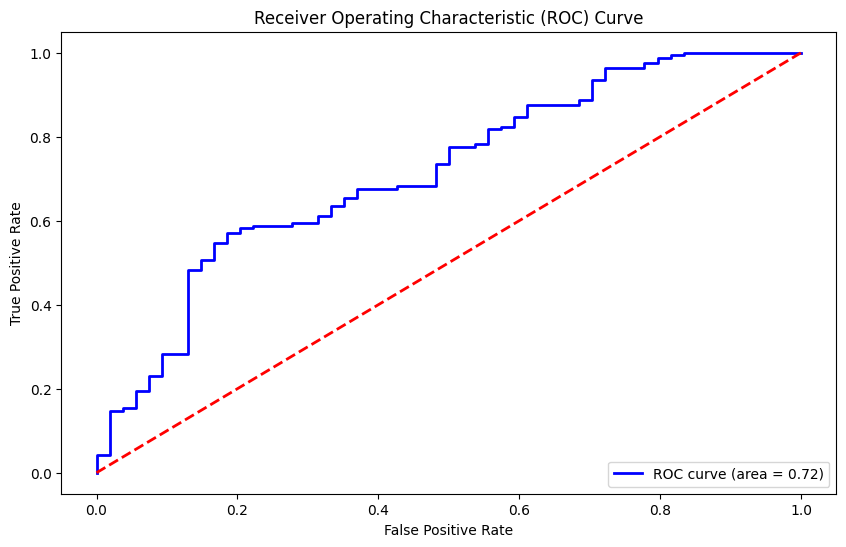

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Assuming your dataset includes the following columns:
# 'embedding_1', 'embedding_2', ..., 'embedding_n' for CXR embeddings
# 'avg_peep' for average PEEP levels
# 'icu_mort' for mortality information

# Step 1: Prepare Data

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
avg_peep = df['avg_peep']
mortality = df['icu_mort']

# Standardize the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

# Apply PCA to reduce dimensionality
pca = PCA(n_components=50)  # You can adjust the number of components based on your dataset
embeddings_pca = pca.fit_transform(embeddings_scaled)

# Combine PCA-transformed embeddings and avg_peep levels
data_pca = pd.DataFrame(embeddings_pca, columns=[f'pca_{i+1}' for i in range(embeddings_pca.shape[1])])
data_pca['avg_peep'] = avg_peep.values

# Step 2: Train a Predictive Model

# Define the input features (X) and the target variable (y)
print (X)
X = data_pca
y = 1 - mortality  # Since we are predicting survival rate, use 1 - icu_mort

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict survival rate on the test set
y_test_prob = model.predict_proba(X_test)[:, 1]  # Probability of survival

# Evaluate the model
test_roc_auc = roc_auc_score(y_test, y_test_prob)
print(f"Test ROC-AUC: {test_roc_auc}")

# Output a table with 5 rows with predicted survival rate, actual mortality, peep, and other raw data
test_indices = X_test.index[:5]
output_data = df.loc[test_indices].copy()
output_data['predicted_survival_rate'] = y_test_prob[:5]
output_data['actual_mortality'] = 1 - y_test[:5]

# Display the output data
print(output_data[['predicted_survival_rate', 'actual_mortality', 'avg_peep'] + embedding_columns].head())

# Optionally, visualize the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % test_roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


   avg_peep  icu_mort  embedding_0  embedding_1  embedding_2  embedding_3  \
0     11.06         1    -1.203857    -0.750460     0.517812    -2.466439   
1     15.80         0    -0.957424    -1.174489     0.746191    -2.606339   
2     14.00         0    -1.211419    -0.097663     0.881380    -1.815136   
3      5.00         0    -0.578595    -2.219270     0.782156    -2.451325   
4     12.55         0    -0.282317    -0.775778     1.007386    -2.592333   

   embedding_4  embedding_5  embedding_6  embedding_7  ...  embedding_1368  \
0     0.678555     0.740019     0.250509     1.054872  ...        0.482153   
1    -0.498505     0.005012     0.473697     0.692004  ...       -0.468487   
2     0.582385     0.303639     1.004069     0.097288  ...        0.836812   
3     0.039926    -0.350579     0.403780    -0.074643  ...       -0.387499   
4     0.268436     0.855181     0.195784     0.444939  ...        1.794152   

   embedding_1369  embedding_1370  embedding_1371  embedding_1372  \

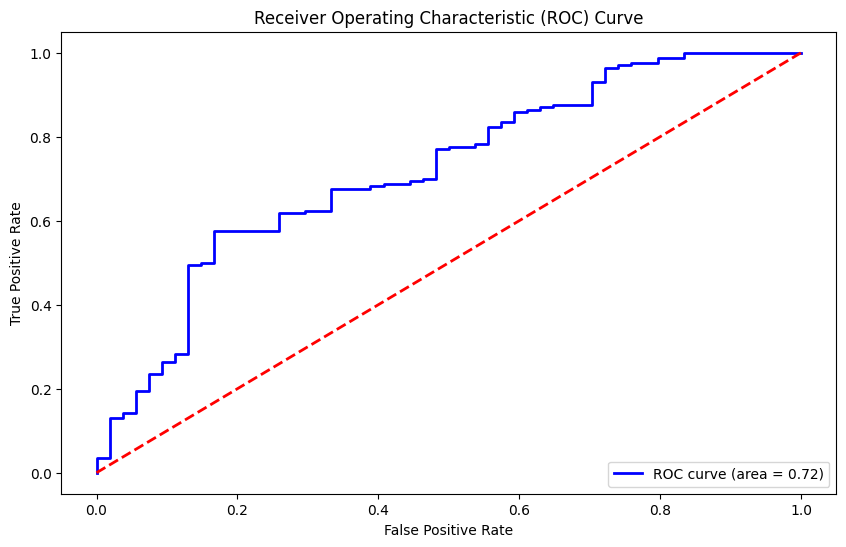

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Assuming your dataset includes the following columns:
# 'embedding_1', 'embedding_2', ..., 'embedding_n' for CXR embeddings
# 'avg_peep' for average PEEP levels
# 'icu_mort' for mortality information

# Step 1: Prepare Data

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
avg_peep = df['avg_peep']
mortality = df['icu_mort']

# Standardize the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

# Apply PCA to reduce dimensionality
pca = PCA(n_components=50)  # You can adjust the number of components based on your dataset
embeddings_pca = pca.fit_transform(embeddings_scaled)

# Combine PCA-transformed embeddings and avg_peep levels
data_pca = pd.DataFrame(embeddings_pca, columns=[f'pca_{i+1}' for i in range(embeddings_pca.shape[1])])
data_pca['avg_peep'] = avg_peep.values

# Define the input features (X) and the target variable (y)
X = data_pca
y = 1 - mortality  # Since we are predicting survival rate, use 1 - icu_mort

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Define another test set from the data for optimization
X_remaining, X_optimize, y_remaining, y_optimize = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# Function to optimize PEEP levels for maximizing survival rate
def optimize_peep(embeddings_pca, model, step=1, range_min=1, range_max=20):
    best_peep = None
    best_prob = 0.0

    for peep in range(range_min, range_max + 1, step):
        temp_data = np.hstack((embeddings_pca.reshape(1, -1), np.array([[peep]])))
        temp_df = pd.DataFrame(temp_data, columns=[f'pca_{i+1}' for i in range(embeddings_pca.shape[0])] + ['avg_peep'])
        temp_prob = model.predict_proba(temp_df)[:, 1][0]
        if temp_prob > best_prob:
            best_prob = temp_prob
            best_peep = peep

    return best_peep, best_prob

# Lists to store results
optimal_peep_levels = []
max_survival_probs = []
raw_data_samples = []

# Optimize PEEP levels for each sample in the optimization set
for i in range(len(X_optimize)):
    patient_embeddings_pca = X_optimize.iloc[i, :-1].values  # Exclude current avg_peep

    optimal_peep, predicted_survival = optimize_peep(patient_embeddings_pca, model)

    optimal_peep_levels.append(optimal_peep)
    max_survival_probs.append(predicted_survival)
    raw_data_samples.append(df.loc[X_optimize.index[i]].to_dict())

# Create a DataFrame with the results
results_df = pd.DataFrame({
    'optimal_peep': optimal_peep_levels,
    'max_survival_prob': max_survival_probs,
    'raw_data': raw_data_samples
})

# Extract columns from the raw data for display
raw_data_df = pd.DataFrame(raw_data_samples)
output_data = raw_data_df[['avg_peep', 'icu_mort'] + embedding_columns].copy()
output_data['optimal_peep'] = results_df['optimal_peep']
output_data['max_survival_prob'] = results_df['max_survival_prob']

# Display the output data
print(output_data.head())

# Optionally, visualize the ROC curve for the initial model
y_test_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
test_roc_auc = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % test_roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


  cluster   avg_peep            icu_mort           high_peep          
                mean       std      mean       std      mean       std
0       0   9.046496  3.221390  0.241935  0.431751  0.387097  0.491062
1       1  10.192579  3.685102  0.213793  0.410691  0.503448  0.500852
High Mortality Cluster: 0
Low Mortality Cluster: 1


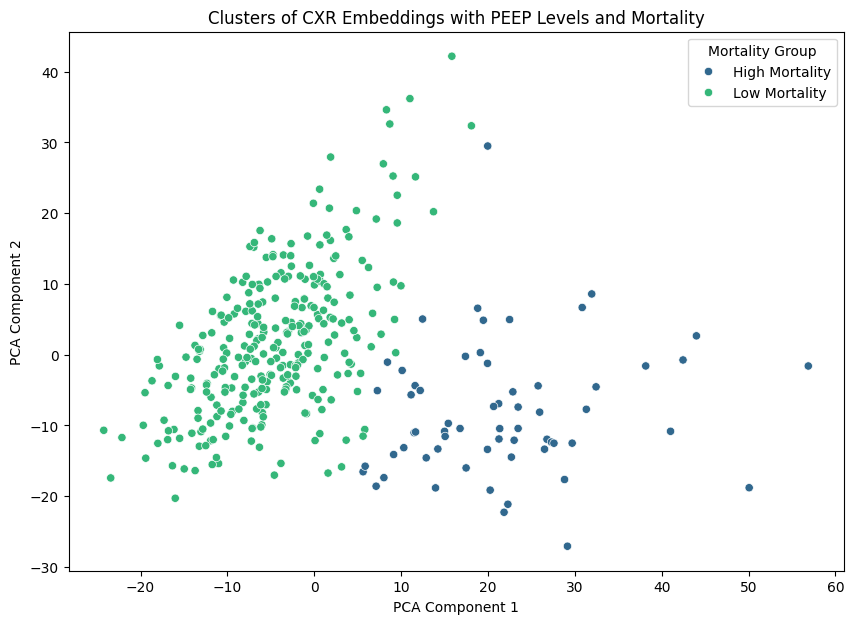

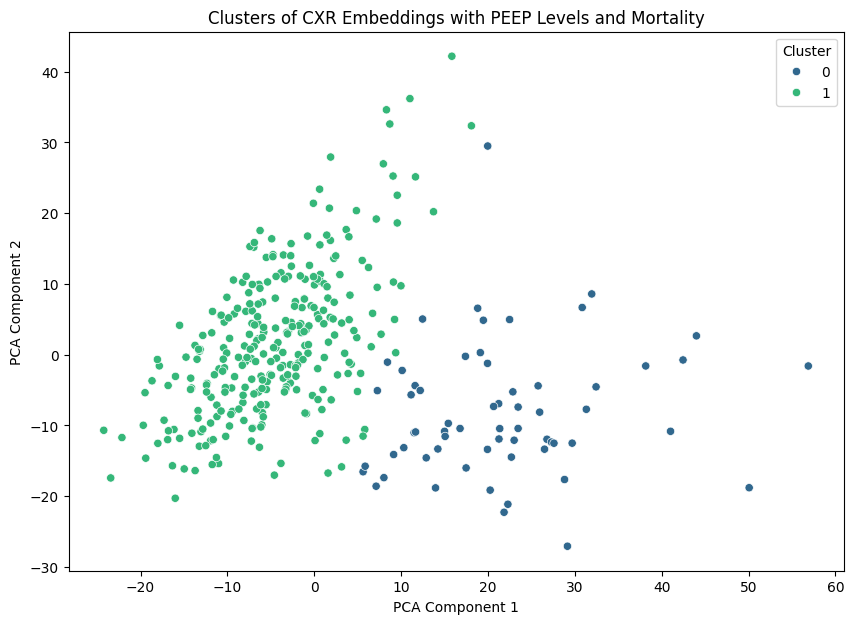

In [ ]:
# Create a binary variable for avg_peep levels
df['high_peep'] = (df['avg_peep'] >= 10).astype(int)
peep_binary = df['high_peep']

# Combine embeddings, PEEP binary, and mortality for clustering
data = pd.concat([embeddings, peep_binary, mortality], axis=1)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Apply PCA
pca = PCA(n_components=50)
data_pca = pca.fit_transform(data_scaled)

# Perform K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(data_pca)

# Add clusters to the DataFrame
df['cluster'] = clusters

# Analyze the clusters
cluster_analysis = df.groupby('cluster').agg({
    'avg_peep': ['mean', 'std'],
    'icu_mort': ['mean', 'std'],
    'high_peep': ['mean', 'std']
}).reset_index()

# Print cluster analysis
print(cluster_analysis)

# Determine which cluster has higher and lower mortality mean
high_mortality_cluster = cluster_analysis['icu_mort']['mean'].idxmax()
low_mortality_cluster = cluster_analysis['icu_mort']['mean'].idxmin()

print(f"High Mortality Cluster: {high_mortality_cluster}")
print(f"Low Mortality Cluster: {low_mortality_cluster}")

# Add mortality group label to the DataFrame
df['mortality_group'] = df['cluster'].apply(lambda x: 'High Mortality' if x == high_mortality_cluster else 'Low Mortality')

# Visualize the clusters by mortality group
plt.figure(figsize=(10, 7))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=df['mortality_group'], palette='viridis')
plt.title('Clusters of CXR Embeddings with PEEP Levels and Mortality')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Mortality Group')
plt.show()

# Visualize the clusters by cluster number
plt.figure(figsize=(10, 7))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=clusters, palette='viridis')
plt.title('Clusters of CXR Embeddings with PEEP Levels and Mortality')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

Best number of clusters: 2
Best Silhouette Score: 0.15409692775315867
  cluster   avg_peep            icu_mort           high_peep          
                mean       std      mean       std      mean       std
0       0   9.046496  3.221390  0.241935  0.431751  0.387097  0.491062
1       1  10.192579  3.685102  0.213793  0.410691  0.503448  0.500852
Significant cluster pairs with mortality differences:


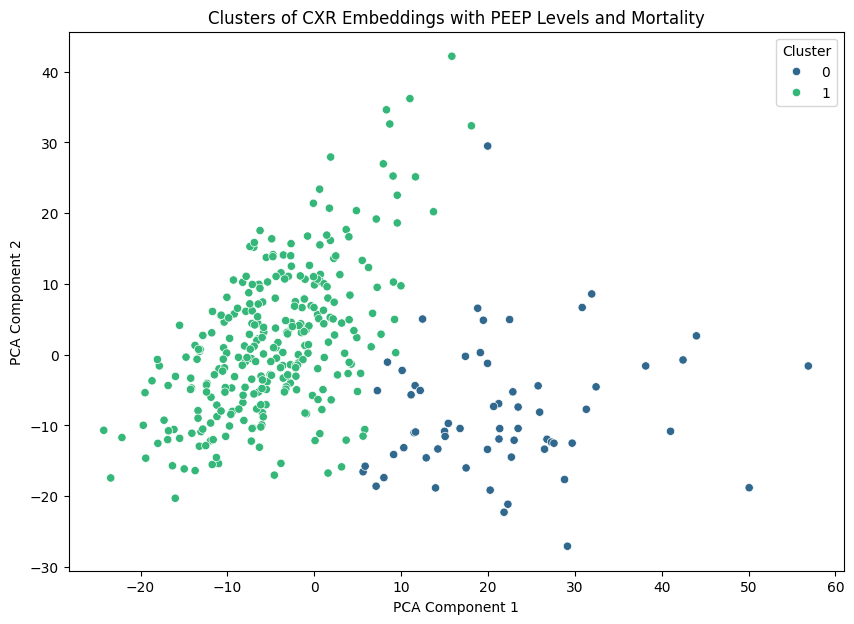

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Assuming your dataset includes the following columns:
# 'embedding_1', 'embedding_2', ..., 'embedding_n' for CXR embeddings
# 'avg_peep' for average PEEP levels
# 'icu_mort' for mortality information

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
avg_peep = df['avg_peep']
mortality = df['icu_mort']

# Create a binary variable for avg_peep levels
df['high_peep'] = (df['avg_peep'] >= 10).astype(int)
peep_binary = df['high_peep']

# Combine embeddings, PEEP binary, and mortality for clustering
data = pd.concat([embeddings, peep_binary, mortality], axis=1)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Apply PCA
pca = PCA(n_components=50)
data_pca = pca.fit_transform(data_scaled)

# Try different numbers of clusters and evaluate
best_n_clusters = 0
best_silhouette_score = -1
best_clusters = None

for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(data_pca)
    score = silhouette_score(data_pca, clusters)
    if score > best_silhouette_score:
        best_silhouette_score = score
        best_n_clusters = n_clusters
        best_clusters = clusters

print(f'Best number of clusters: {best_n_clusters}')
print(f'Best Silhouette Score: {best_silhouette_score}')

# Add the best clusters to the DataFrame
df['cluster'] = best_clusters

# Analyze the clusters
cluster_analysis = df.groupby('cluster').agg({
    'avg_peep': ['mean', 'std'],
    'icu_mort': ['mean', 'std'],
    'high_peep': ['mean', 'std']
}).reset_index()

print(cluster_analysis)

# Perform t-tests to find significant differences in mortality
cluster_mortality = df.groupby('cluster')['icu_mort'].mean()
significant_clusters = []

for i in range(best_n_clusters):
    for j in range(i+1, best_n_clusters):
        t_stat, p_value = ttest_ind(
            df[df['cluster'] == i]['icu_mort'],
            df[df['cluster'] == j]['icu_mort'],
            equal_var=False
        )
        if p_value < 0.05:  # Using 5% significance level
            significant_clusters.append((i, j, p_value))

print('Significant cluster pairs with mortality differences:')
for pair in significant_clusters:
    print(f'Cluster {pair[0]} vs Cluster {pair[1]}: p-value = {pair[2]}')

# Visualize the clusters by mortality group
plt.figure(figsize=(10, 7))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=df['cluster'], palette='viridis')
plt.title('Clusters of CXR Embeddings with PEEP Levels and Mortality')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()


Best number of clusters: 2
Best Silhouette Score: 0.15078637069119658
  cluster   avg_peep            icu_mort           high_peep          
                mean       std      mean       std      mean       std
0       0  10.176280  3.671942  0.215278  0.411730  0.503472  0.500858
1       1   9.155658  3.334554  0.234375  0.426956  0.390625  0.491747
Significant cluster pairs with mortality differences:


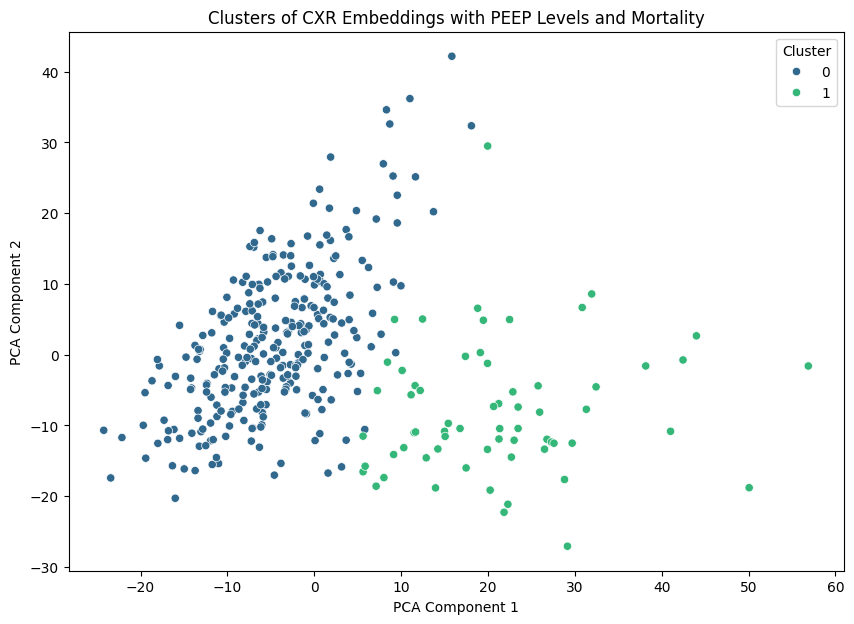

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Assuming your dataset includes the following columns:
# 'embedding_1', 'embedding_2', ..., 'embedding_n' for CXR embeddings
# 'avg_peep' for average PEEP levels
# 'icu_mort' for mortality information

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
avg_peep = df['avg_peep']
mortality = df['icu_mort']

# Create a binary variable for avg_peep levels
df['high_peep'] = (df['avg_peep'] >= 10).astype(int)
peep_binary = df['high_peep']

# Combine embeddings, PEEP binary, and mortality for clustering
data = pd.concat([embeddings, peep_binary, mortality], axis=1)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Apply PCA
pca = PCA(n_components=50)
data_pca = pca.fit_transform(data_scaled)

# Try different numbers of clusters and evaluate
best_n_clusters = 0
best_silhouette_score = -1
best_clusters = None

for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(data_pca)
    score = silhouette_score(data_pca, clusters)
    if score > best_silhouette_score:
        best_silhouette_score = score
        best_n_clusters = n_clusters
        best_clusters = clusters

print(f'Best number of clusters: {best_n_clusters}')
print(f'Best Silhouette Score: {best_silhouette_score}')

# Add the best clusters to the DataFrame
df['cluster'] = best_clusters

# Analyze the clusters
cluster_analysis = df.groupby('cluster').agg({
    'avg_peep': ['mean', 'std'],
    'icu_mort': ['mean', 'std'],
    'high_peep': ['mean', 'std']
}).reset_index()

print(cluster_analysis)

# Perform t-tests to find significant differences in mortality
cluster_mortality = df.groupby('cluster')['icu_mort'].mean()
significant_clusters = []

for i in range(best_n_clusters):
    for j in range(i+1, best_n_clusters):
        t_stat, p_value = ttest_ind(
            df[df['cluster'] == i]['icu_mort'],
            df[df['cluster'] == j]['icu_mort'],
            equal_var=False
        )
        if p_value < 0.05:  # Using 5% significance level
            significant_clusters.append((i, j, p_value))

print('Significant cluster pairs with mortality differences:')
for pair in significant_clusters:
    print(f'Cluster {pair[0]} vs Cluster {pair[1]}: p-value = {pair[2]}')

# Visualize the clusters by mortality group
plt.figure(figsize=(10, 7))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=df['cluster'], palette='viridis')
plt.title('Clusters of CXR Embeddings with PEEP Levels and Mortality')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()


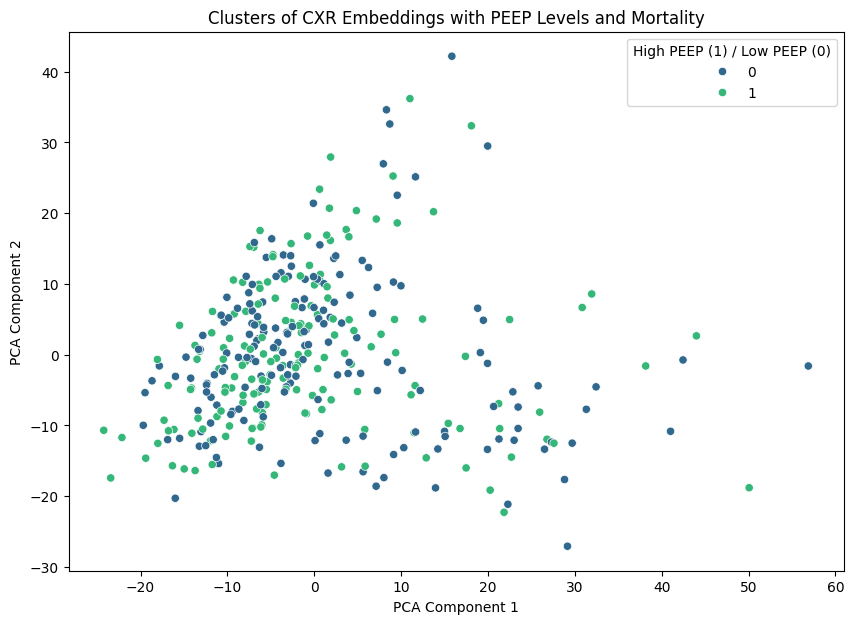

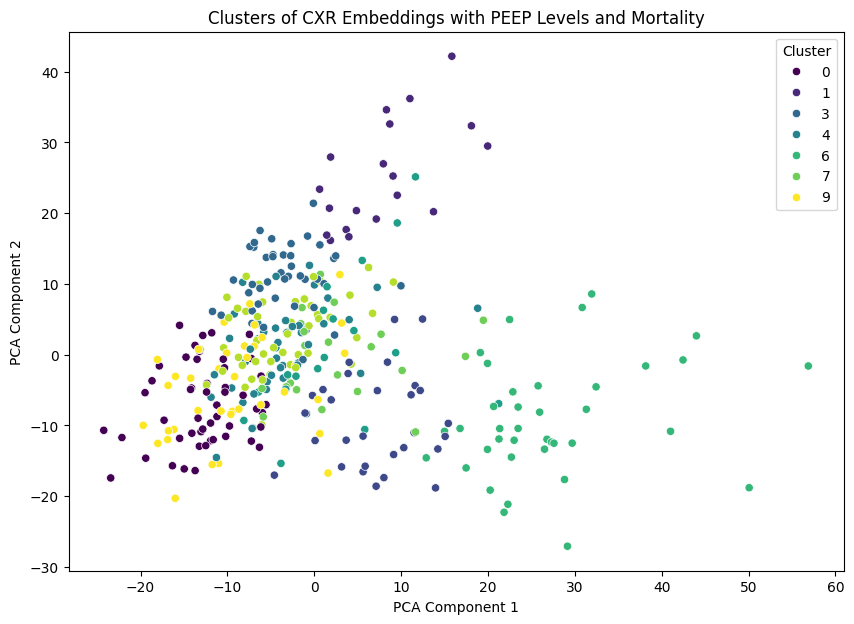

In [ ]:
# Visualize the clusters by high PEEP / low PEEP
plt.figure(figsize=(10, 7))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=df['high_peep'], palette='viridis')
plt.title('Clusters of CXR Embeddings with PEEP Levels and Mortality')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='High PEEP (1) / Low PEEP (0)')
plt.show()

# Visualize the clusters by cluster number
plt.figure(figsize=(10, 7))
sns.scatterplot(x=data_pca[:, 0], y=data_pca[:, 1], hue=clusters, palette='viridis')
plt.title('Clusters of CXR Embeddings with PEEP Levels and Mortality')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

Best number of clusters: 2
Best Silhouette Score: 0.42214318340110263
  cluster   avg_peep            icu_mort           high_peep          
                mean       std      mean       std      mean       std
0       0  10.158402  3.683655  0.210884  0.408632  0.500000  0.500853
1       1   9.140699  3.241025  0.258621  0.441701  0.396552  0.493454
Significant cluster pairs with mortality differences:


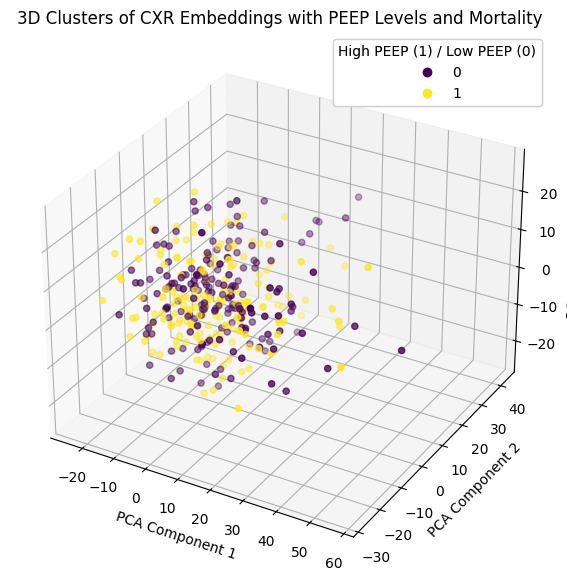

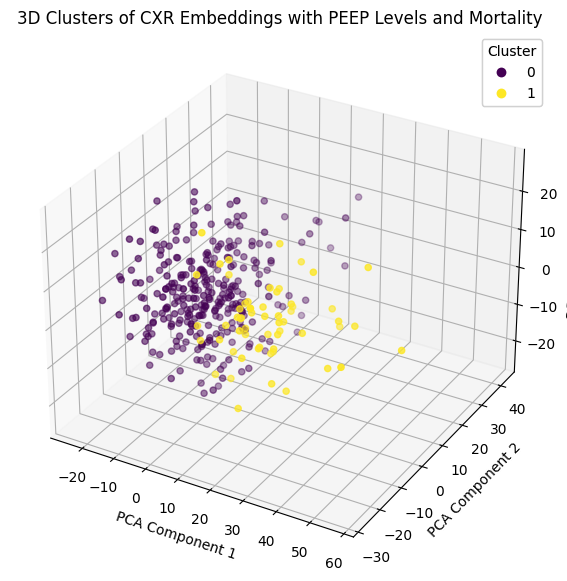

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import ttest_ind

# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Assuming your dataset includes the following columns:
# 'embedding_1', 'embedding_2', ..., 'embedding_n' for CXR embeddings
# 'avg_peep' for average PEEP levels
# 'icu_mort' for mortality information

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
avg_peep = df['avg_peep']
mortality = df['icu_mort']

# Create a binary variable for avg_peep levels
df['high_peep'] = (df['avg_peep'] >= 10).astype(int)
peep_binary = df['high_peep']

# Combine embeddings, PEEP binary, and mortality for clustering
data = pd.concat([embeddings, peep_binary, mortality], axis=1)

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Apply PCA
pca = PCA(n_components=3)
data_pca = pca.fit_transform(data_scaled)

# Try different numbers of clusters and evaluate
best_n_clusters = 0
best_silhouette_score = -1
best_clusters = None

for n_clusters in range(2, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(data_pca)
    score = silhouette_score(data_pca, clusters)
    if score > best_silhouette_score:
        best_silhouette_score = score
        best_n_clusters = n_clusters
        best_clusters = clusters

print(f'Best number of clusters: {best_n_clusters}')
print(f'Best Silhouette Score: {best_silhouette_score}')

# Add the best clusters to the DataFrame
df['cluster'] = best_clusters

# Analyze the clusters
cluster_analysis = df.groupby('cluster').agg({
    'avg_peep': ['mean', 'std'],
    'icu_mort': ['mean', 'std'],
    'high_peep': ['mean', 'std']
}).reset_index()

print(cluster_analysis)

# Perform t-tests to find significant differences in mortality
cluster_mortality = df.groupby('cluster')['icu_mort'].mean()
significant_clusters = []

for i in range(best_n_clusters):
    for j in range(i+1, best_n_clusters):
        t_stat, p_value = ttest_ind(
            df[df['cluster'] == i]['icu_mort'],
            df[df['cluster'] == j]['icu_mort'],
            equal_var=False
        )
        if p_value < 0.05:  # Using 5% significance level
            significant_clusters.append((i, j, p_value))

print('Significant cluster pairs with mortality differences:')
for pair in significant_clusters:
    print(f'Cluster {pair[0]} vs Cluster {pair[1]}: p-value = {pair[2]}')

# 3D Visualization of the clusters by high PEEP / low PEEP
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(data_pca[:, 0], data_pca[:, 1], data_pca[:, 2], c=df['high_peep'], cmap='viridis')
legend1 = ax.legend(*scatter.legend_elements(), title="High PEEP (1) / Low PEEP (0)")
ax.add_artist(legend1)
ax.set_title('3D Clusters of CXR Embeddings with PEEP Levels and Mortality')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
plt.show()

# 3D Visualization of the clusters by cluster number
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(data_pca[:, 0], data_pca[:, 1], data_pca[:, 2], c=best_clusters, cmap='viridis')
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
ax.set_title('3D Clusters of CXR Embeddings with PEEP Levels and Mortality')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
plt.show()


Test ROC-AUC: 0.720806100217865


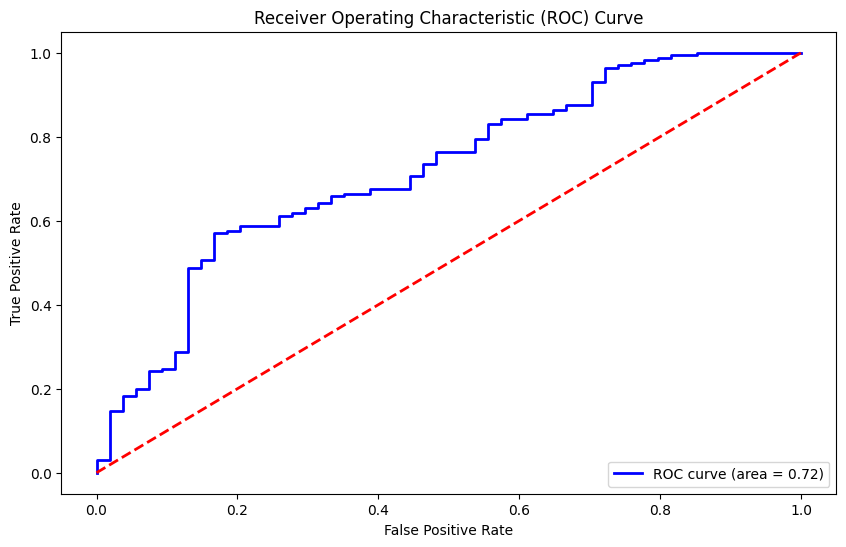

In [ ]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Assuming your dataset includes the following columns:
# 'embedding_1', 'embedding_2', ..., 'embedding_n' for CXR embeddings
# 'avg_peep' for average PEEP levels
# 'icu_mort' for mortality information

# Step 1: Prepare Data

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
avg_peep = df['avg_peep']
mortality = df['icu_mort']

# Standardize the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

# Apply PCA to reduce dimensionality
pca = PCA(n_components=50)  # You can adjust the number of components based on your dataset
embeddings_pca = pca.fit_transform(embeddings_scaled)

# Combine PCA-transformed embeddings and avg_peep levels
data_pca = pd.DataFrame(embeddings_pca, columns=[f'pca_{i+1}' for i in range(embeddings_pca.shape[1])])
data_pca['avg_peep'] = avg_peep.values

# Step 2: Train a Predictive Model

# Define the input features (X) and the target variable (y)
X = data_pca
y = 1 - mortality  # Since we are predicting survival rate, use 1 - icu_mort

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict survival rate on the test set
y_test_prob = model.predict_proba(X_test)[:, 1]  # Probability of survival

# Evaluate the model
test_roc_auc = roc_auc_score(y_test, y_test_prob)
print(f"Test ROC-AUC: {test_roc_auc}")

# Visualize the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % test_roc_auc)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Not working: Clustering + Pairing closest points to find optimum decision

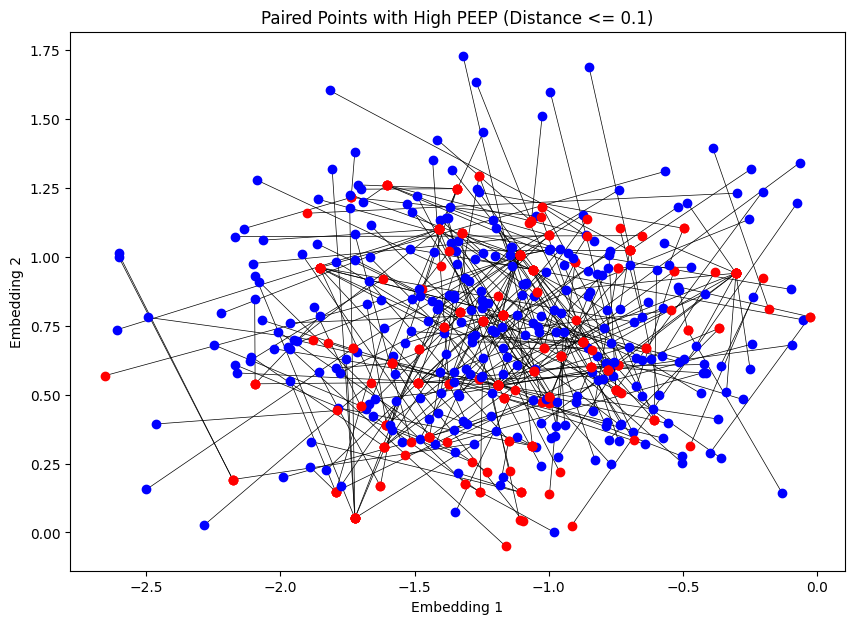

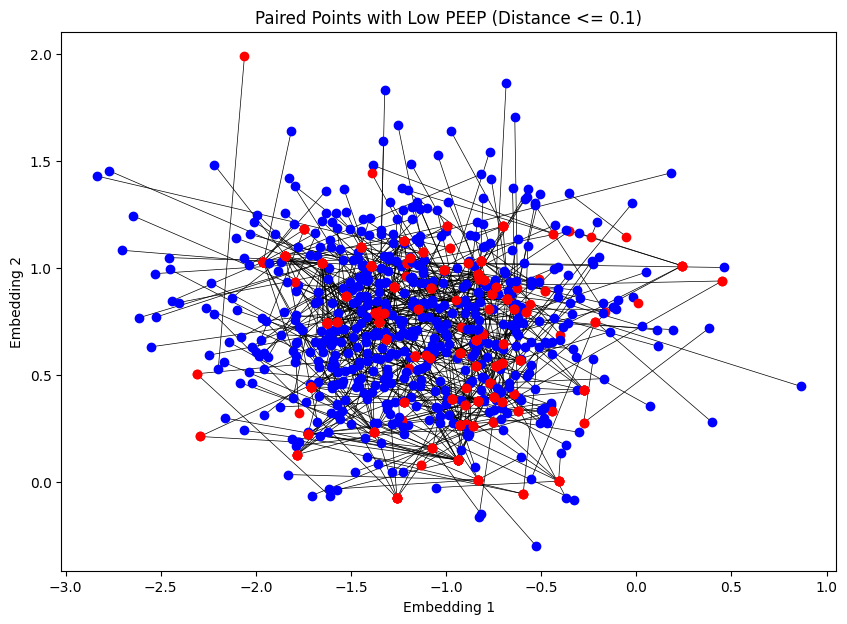

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Assuming your dataset includes the following columns:
# 'embedding_1', 'embedding_2', ..., 'embedding_n' for CXR embeddings
# 'avg_peep' for average PEEP levels
# 'icu_mort' for mortality information

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
avg_peep = df['avg_peep']
mortality = df['icu_mort']

# Create a binary variable for avg_peep levels
df['high_peep'] = (df['avg_peep'] >= 10).astype(int)
peep_binary = df['high_peep']

# Pair the points based on the criteria
pairs = []
for peep_value in [0, 1]:  # For low_peep (0) and high_peep (1)
    sub_df = df[(df['high_peep'] == peep_value)]

    # Find pairs with different mortality outcomes
    survival = sub_df[sub_df['icu_mort'] == 0]
    death = sub_df[sub_df['icu_mort'] == 1]

    # Calculate pairwise distances and find closest pairs
    distances = cdist(survival[embedding_columns], death[embedding_columns])
    for i, row in enumerate(distances):
        min_index = np.argmin(row)
        min_distance = row[min_index]
        pairs.append((survival.index[i], death.index[min_index], peep_value))

# Separate the paired data for high and low PEEP
high_peep_pairs = [pair for pair in pairs if pair[2] == 1]
low_peep_pairs = [pair for pair in pairs if pair[2] == 0]

# Function to plot paired points
def plot_pairs(pairs, title):
    paired_indices = [index for pair in pairs for index in pair[:2]]
    df_paired = df.loc[paired_indices].reset_index(drop=True)

    plt.figure(figsize=(10, 7))

    # Extracting embedding for first two components (or replace with PCA if needed)
    x_values = df_paired['embedding_1']
    y_values = df_paired['embedding_2']

    for i in range(0, len(df_paired), 2):
        plt.plot(
            [x_values[i], x_values[i+1]],
            [y_values[i], y_values[i+1]],
            'k-', lw=0.5, zorder=1  # Draw a line between the pair
        )
        plt.scatter(x_values[i], y_values[i], color='blue' if df_paired['icu_mort'][i] == 0 else 'red', zorder=2)
        plt.scatter(x_values[i+1], y_values[i+1], color='blue' if df_paired['icu_mort'][i+1] == 0 else 'red', zorder=2)

    plt.title(title)
    plt.xlabel('Embedding 1')
    plt.ylabel('Embedding 2')
    plt.show()

# Plot for High PEEP pairs
plot_pairs(high_peep_pairs, 'Paired Points with High PEEP (Distance <= 0.1)')

# Plot for Low PEEP pairs
plot_pairs(low_peep_pairs, 'Paired Points with Low PEEP (Distance <= 0.1)')


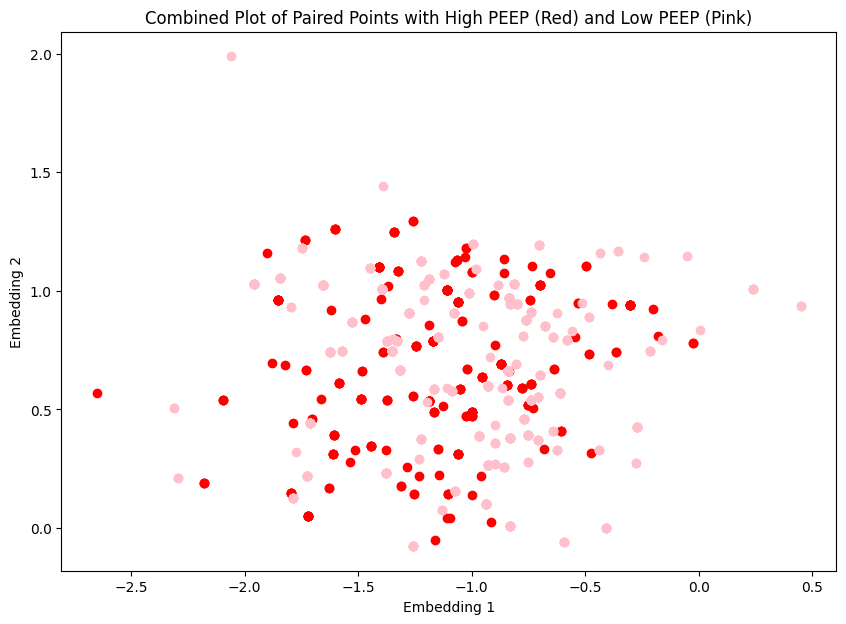

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Load your dataset into a pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Assuming your dataset includes the following columns:
# 'embedding_1', 'embedding_2', ..., 'embedding_n' for CXR embeddings
# 'avg_peep' for average PEEP levels
# 'icu_mort' for mortality information

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
avg_peep = df['avg_peep']
mortality = df['icu_mort']

# Create a binary variable for avg_peep levels
df['high_peep'] = (df['avg_peep'] >= 10).astype(int)
peep_binary = df['high_peep']

# Pair the points based on the criteria
pairs = []
for peep_value in [0, 1]:  # For low_peep (0) and high_peep (1)
    sub_df = df[(df['high_peep'] == peep_value)]

    # Find pairs with different mortality outcomes
    survival = sub_df[sub_df['icu_mort'] == 0]
    death = sub_df[sub_df['icu_mort'] == 1]

    # Calculate pairwise distances and find closest pairs
    distances = cdist(survival[embedding_columns], death[embedding_columns])
    for i, row in enumerate(distances):
        min_index = np.argmin(row)
        min_distance = row[min_index]
        pairs.append((survival.index[i], death.index[min_index], peep_value))

# Separate the paired data for high and low PEEP
high_peep_pairs = [pair for pair in pairs if pair[2] == 1]
low_peep_pairs = [pair for pair in pairs if pair[2] == 0]

# Plot the combined paired points
plt.figure(figsize=(10, 7))

# Function to plot paired points without blue dots and with color differentiation
def plot_pairs(pairs, color):
    paired_indices = [index for pair in pairs for index in pair[:2]]
    df_paired = df.loc[paired_indices].reset_index(drop=True)

    # Extracting embedding for first two components
    x_values = df_paired['embedding_1']
    y_values = df_paired['embedding_2']

    for i in range(0, len(df_paired), 2):
        # Only plot the points representing death (remove the blue dots)
        plt.plot(
            [x_values[i+1], x_values[i+1]],  # Keep the death point stationary
            [y_values[i+1], y_values[i+1]],
            'k-', lw=0.5, zorder=1  # Draw a line between the pair (will not be visible since it is stationary)
        )
        plt.scatter(x_values[i+1], y_values[i+1], color=color, zorder=2)  # Color based on PEEP

# Plot high PEEP pairs in red
plot_pairs(high_peep_pairs, 'red')

# Plot low PEEP pairs in pink
plot_pairs(low_peep_pairs, 'pink')

plt.title('Combined Plot of Paired Points with High PEEP (Red) and Low PEEP (Pink)')
plt.xlabel('Embedding 1')
plt.ylabel('Embedding 2')
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance

# Assuming your dataset includes the following columns:
# 'embedding_1', 'embedding_2', ..., 'embedding_n' for CXR embeddings
# 'avg_peep' for average PEEP levels
# 'icu_mort' for mortality information

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns].astype(float)  # Ensure embeddings are float
avg_peep = df['avg_peep']
mortality = df['icu_mort']

# Create a binary variable for avg_peep levels
df['high_peep'] = (df['avg_peep'] >= 10).astype(int)

# Randomly select 10% of the data points as test points
test_indices = df.sample(frac=0.1, random_state=42).index
test_points = df.loc[test_indices]

# Exclude these points from the dataset for the plot and analysis
remaining_df = df.drop(test_indices)

# Function to calculate distribution within a circular region
def calculate_distribution(center_point, remaining_df, radius=0.5):
    distances = distance.cdist([center_point], remaining_df[embedding_columns])[0]
    within_radius = remaining_df[distances <= radius]

    # Calculate the distribution of the four categories
    distribution = within_radius.groupby(['high_peep', 'icu_mort']).size().unstack(fill_value=0)
    # Ensure all four combinations are present in the index, even if they have zero counts
    distribution = distribution.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    return distribution

# Initialize a list to store the results
results = []

# Iterate over each test point
for idx, test_point in test_points.iterrows():
    center_point = test_point[embedding_columns].values.astype(float)  # Ensure center_point is float
    distribution = calculate_distribution(center_point, remaining_df)

    # Determine which PEEP level is more likely to lead to survival
    high_peep_survival = distribution.loc[1, 0]  # Access using integer index
    low_peep_survival = distribution.loc[0, 0]   # Access using integer index


    if high_peep_survival > low_peep_survival:
        likely_peep = "High PEEP"
    else:
        likely_peep = "Low PEEP"

    results.append({
        'Test Point Index': idx,
        'High PEEP Death': distribution.loc[(1, 1)],
        'High PEEP Survival': distribution.loc[(1, 0)],
        'Low PEEP Death': distribution.loc[(0, 1)],
        'Low PEEP Survival': distribution.loc[(0, 0)],
        'Likely to Survive with': likely_peep
    })

# Convert results to a DataFrame and display it
results_df = pd.DataFrame(results)
results_df.index.name = 'Test Point'
results_df.reset_index(inplace=True)

# Output the results table
print(results_df)


     Test Point  Test Point Index  High PEEP Death  High PEEP Survival  \
0             0               994                0                   0   
1             1               101                0                   0   
2             2               486                0                   0   
3             3               862                0                   0   
4             4              1076                0                   0   
..          ...               ...              ...                 ...   
107         107               425                0                   0   
108         108               247                0                   0   
109         109                49                0                   0   
110         110               107                0                   0   
111         111                59                0                   0   

     Low PEEP Death  Low PEEP Survival Likely to Survive with  
0                 0                  0         

In [ ]:
# Define the four categories based on 'high_peep' and 'icu_mort'
high_peep_death = df[(df['high_peep'] == 1) & (df['icu_mort'] == 1)]
high_peep_survival = df[(df['high_peep'] == 1) & (df['icu_mort'] == 0)]
low_peep_death = df[(df['high_peep'] == 0) & (df['icu_mort'] == 1)]
low_peep_survival = df[(df['high_peep'] == 0) & (df['icu_mort'] == 0)]

# Count the number of occurrences in each category
high_peep_death_count = len(high_peep_death)
high_peep_survival_count = len(high_peep_survival)
low_peep_death_count = len(low_peep_death)
low_peep_survival_count = len(low_peep_survival)

# Print the counts
print("High PEEP with Mortality = 1 (Death):", high_peep_death_count)
print("High PEEP with Mortality = 0 (Survival):", high_peep_survival_count)
print("Low PEEP with Mortality = 1 (Death):", low_peep_death_count)
print("Low PEEP with Mortality = 0 (Survival):", low_peep_survival_count)
# Randomly select 128 samples from each category
high_peep_death_sample = high_peep_death.sample(n=128, random_state=42)
high_peep_survival_sample = high_peep_survival.sample(n=128, random_state=42)
low_peep_death_sample = low_peep_death.sample(n=128, random_state=42)
low_peep_survival_sample = low_peep_survival.sample(n=128, random_state=42)

# Combine the samples into a single DataFrame
combined_samples = pd.concat([
    high_peep_death_sample,
    high_peep_survival_sample,
    low_peep_death_sample,
    low_peep_survival_sample
])

# Extract the embedding data from the combined samples
embedding_samples = combined_samples[embedding_columns]

High PEEP with Mortality = 1 (Death): 136
High PEEP with Mortality = 0 (Survival): 299
Low PEEP with Mortality = 1 (Death): 128
Low PEEP with Mortality = 0 (Survival): 554


In [ ]:
# Randomly select 128 samples from each category
high_peep_death_sample = high_peep_death.sample(n=128, random_state=42)
high_peep_survival_sample = high_peep_survival.sample(n=128, random_state=42)
low_peep_death_sample = low_peep_death.sample(n=128, random_state=42)
low_peep_survival_sample = low_peep_survival.sample(n=128, random_state=42)

# Combine the samples into a single DataFrame
combined_samples = pd.concat([
    high_peep_death_sample,
    high_peep_survival_sample,
    low_peep_death_sample,
    low_peep_survival_sample
])

# Extract the embedding data from the combined samples
embedding_samples = combined_samples[embedding_columns]


In [ ]:
from sklearn.cluster import KMeans

# Define the number of clusters (you can choose a number, e.g., 4 for each category)
num_clusters = 4

# Perform K-Means clustering on the embeddings
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
combined_samples['cluster'] = kmeans.fit_predict(embedding_samples)

# Print the number of points in each cluster
print(combined_samples['cluster'].value_counts())


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


cluster
3    176
0    156
2    108
1     72
Name: count, dtype: int64


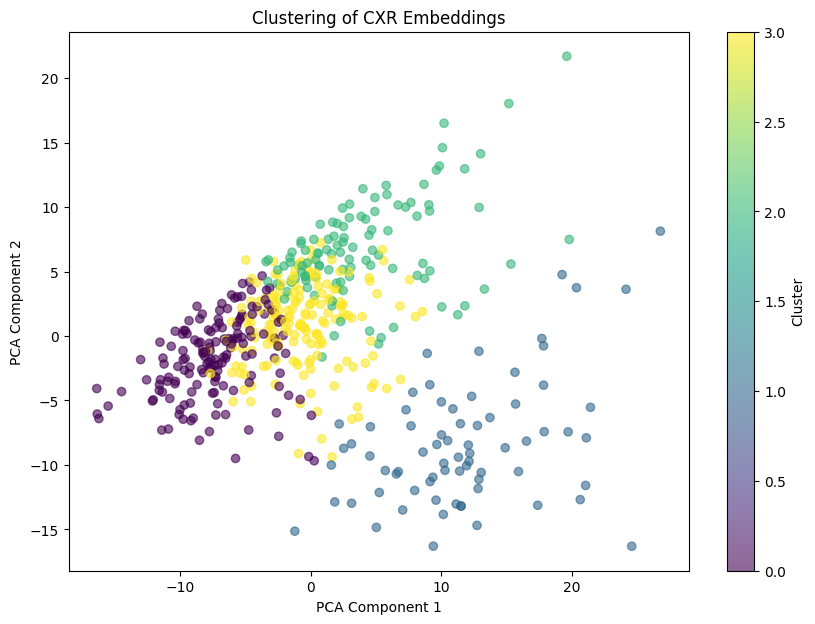

In [ ]:
from sklearn.decomposition import PCA

# Reduce the embeddings to 2 dimensions for visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embedding_samples)

# Plot the clusters
plt.figure(figsize=(10, 7))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=combined_samples['cluster'], cmap='viridis', alpha=0.6)
plt.title('Clustering of CXR Embeddings')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance

# Assuming you have already created 'combined_samples' from your previous steps.
# Replace df with combined_samples for the chosen data.

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in combined_samples.columns if col.startswith('embedding_')]
embeddings = combined_samples[embedding_columns].astype(float)  # Ensure embeddings are float
avg_peep = combined_samples['avg_peep']
mortality = combined_samples['icu_mort']

# Randomly select 10% of the data points as test points
test_indices = combined_samples.sample(frac=0.1, random_state=42).index
test_points = combined_samples.loc[test_indices]

# Exclude these points from the dataset for the plot and analysis
remaining_df = combined_samples.drop(test_indices)

# Function to calculate distribution within a circular region
def calculate_distribution(center_point, remaining_df, radius=0.5):
    distances = distance.cdist([center_point], remaining_df[embedding_columns])[0]
    within_radius = remaining_df[distances <= radius]

    # Calculate the distribution of the four categories
    distribution = within_radius.groupby(['high_peep', 'icu_mort']).size().unstack(fill_value=0)
    # Ensure all four combinations are present in the index, even if they have zero counts
    distribution = distribution.reindex(index=[0, 1], columns=[0, 1], fill_value=0)

    return distribution

# Initialize a list to store the results
results = []

# Iterate over each test point
for idx, test_point in test_points.iterrows():
    center_point = test_point[embedding_columns].values.astype(float)  # Ensure center_point is float
    distribution = calculate_distribution(center_point, remaining_df)

    # Determine which PEEP level is more likely to lead to survival
    high_peep_survival = distribution.loc[1, 0]  # Access using integer index
    low_peep_survival = distribution.loc[0, 0]   # Access using integer index

    if high_peep_survival > low_peep_survival:
        likely_peep = "High PEEP"
    else:
        likely_peep = "Low PEEP"

    results.append({
        'Test Point Index': idx,
        'High PEEP Death': distribution.loc[(1, 1)],
        'High PEEP Survival': distribution.loc[(1, 0)],
        'Low PEEP Death': distribution.loc[(0, 1)],
        'Low PEEP Survival': distribution.loc[(0, 0)],
        'Likely to Survive with': likely_peep
    })

# Convert results to a DataFrame and display it
results_df = pd.DataFrame(results)
results_df.index.name = 'Test Point'
results_df.reset_index(inplace=True)

# Output the results table
print(results_df)


    Test Point  Test Point Index  High PEEP Death  High PEEP Survival  \
0            0               613                0                   0   
1            1               507                0                   0   
2            2               390                0                   0   
3            3              1008                0                   0   
4            4                36                0                   0   
5            5                23                0                   0   
6            6               273                0                   0   
7            7              1055                0                   0   
8            8               933                0                   0   
9            9               179                0                   0   
10          10               250                0                   0   
11          11               950                0                   0   
12          12               219                0  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance

# Assuming you have already created 'combined_samples' from your previous steps.
# Replace df with combined_samples for the chosen data.

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in combined_samples.columns if col.startswith('embedding_')]
embeddings = combined_samples[embedding_columns].astype(float)  # Ensure embeddings are float
avg_peep = combined_samples['avg_peep']
mortality = combined_samples['icu_mort']

# Randomly select 10% of the data points as test points
test_indices = combined_samples.sample(frac=0.1, random_state=42).index
test_points = combined_samples.loc[test_indices]

# Exclude these points from the dataset for finding the closest points
remaining_df = combined_samples.drop(test_indices)

# Initialize a list to store the results
results = []

# Iterate over each test point
for idx, test_point in test_points.iterrows():
    center_point = test_point[embedding_columns].values.astype(float)  # Ensure center_point is float

    # Calculate the distance to all other points
    distances = distance.cdist([center_point], remaining_df[embedding_columns])[0]

    # Find the index of the closest point
    closest_index = remaining_df.index[np.argmin(distances)]

    # Get the corresponding closest point's data
    closest_point = remaining_df.loc[closest_index]

    # Determine the decision based on the mortality of the closest point
    if closest_point['icu_mort'] == 0:
        likely_peep = "High PEEP" if closest_point['high_peep'] == 1 else "Low PEEP"
    else:
        likely_peep = "Low PEEP" if closest_point['high_peep'] == 1 else "High PEEP"

    results.append({
        'Test Point Index': idx,
        'Closest Point Index': closest_index,
        'Closest Point Mortality': closest_point['icu_mort'],
        'Closest Point PEEP': "High PEEP" if closest_point['high_peep'] == 1 else "Low PEEP",
        'Actual Decision Made': likely_peep
    })

# Convert results to a DataFrame and display it
results_df = pd.DataFrame(results)
results_df.index.name = 'Test Point'
results_df.reset_index(inplace=True)

# Output the results table
print(results_df)



    Test Point  Test Point Index  Closest Point Index  \
0            0               613                  790   
1            1               507                  412   
2            2               390                  636   
3            3              1008                  817   
4            4                36                   74   
5            5                23                  172   
6            6               273                  363   
7            7              1055                  994   
8            8               933                  931   
9            9               179                  187   
10          10               250                  249   
11          11               950                  205   
12          12               219                  218   
13          13                65                  542   
14          14               366                   41   
15          15               973                  972   
16          16               78

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import distance

# Assuming you have already created 'combined_samples' from your previous steps.
# Replace df with combined_samples for the chosen data.

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in combined_samples.columns if col.startswith('embedding_')]
embeddings = combined_samples[embedding_columns].astype(float)  # Ensure embeddings are float
avg_peep = combined_samples['avg_peep']
mortality = combined_samples['icu_mort']

# Randomly select 10% of the data points as test points
test_indices = combined_samples.sample(frac=0.1, random_state=42).index
test_points = combined_samples.loc[test_indices]

# Exclude these points from the dataset for finding the closest points
remaining_df = combined_samples.drop(test_indices)

# Initialize a list to store the results
results = []

# Iterate over each test point
for idx, test_point in test_points.iterrows():
    center_point = test_point[embedding_columns].values.astype(float)  # Ensure center_point is float

    # Calculate the distance to all other points
    distances = distance.cdist([center_point], remaining_df[embedding_columns])[0]

    # Find the index of the closest point
    closest_index = remaining_df.index[np.argmin(distances)]

    # Get the corresponding closest point's data
    closest_point = remaining_df.loc[closest_index]

    # Determine the decision based on the mortality of the closest point
    if closest_point['icu_mort'] == 0:
        likely_peep = "High PEEP" if closest_point['high_peep'] == 1 else "Low PEEP"
    else:
        likely_peep = "Low PEEP" if closest_point['high_peep'] == 1 else "High PEEP"

    # Classify the actual avg_peep level of the test point
    actual_peep_classification = "High PEEP" if test_point['avg_peep'] >= 10 else "Low PEEP"

    # Check if the actual decision matches the avg_peep level classification
    match_decision = "Match" if likely_peep == actual_peep_classification else "No Match"

    results.append({
        'Test Point Index': idx,
        'Actual Avg PEEP': test_point['avg_peep'],
        'Closest Point Index': closest_index,
        'Closest Point Mortality': closest_point['icu_mort'],
        'Closest Point PEEP': "High PEEP" if closest_point['high_peep'] == 1 else "Low PEEP",
        'Actual Decision Made': likely_peep,
        'Decision Match with Avg PEEP': match_decision
    })

# Convert results to a DataFrame and display it
results_df = pd.DataFrame(results)
results_df.index.name = 'Test Point'
results_df.reset_index(inplace=True)

# Output the results table
print(results_df)


    Test Point  Test Point Index  Actual Avg PEEP  Closest Point Index  \
0            0               613         9.000000                  790   
1            1               507         5.100000                  412   
2            2               390         5.000000                  636   
3            3              1008        10.750000                  817   
4            4                36         5.000000                   74   
5            5                23        13.650000                  172   
6            6               273        14.300000                  363   
7            7              1055         7.285714                  994   
8            8               933         8.325000                  931   
9            9               179        18.100000                  187   
10          10               250         6.133333                  249   
11          11               950         7.285714                  205   
12          12               219      

# Discussion about the code

 For this code, we find the most similar cxr data and follow the decision of the closest data point if it lead to survival.

 The limitation is that it simply suggests to do the opposite decision when when the decision of closest data point lead to death.

 Improvements: For the decisions which lead to death, assess the image to find whether that decision was appropriate or not to give correct decision
 The problem with this improvement would be that it won't be clear to prove whether the decision is appropriate or not.

 What we can do is for high peep leading to survival, classify them as the "appropriate candidate" for high peeps

 high peep leading to death we classify them in two categories being: "actually ill" or "misjudged"

 Low peep leading to survival is "correct" leading to death would be "Anomaly, or other organ failure"


 The most important part of this is to classify for the high peep leading to death as are they actually ill or are they misjudged?

# Prediction model (data preparation)

Divide the data

In [1]:
import os
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from google.colab import auth
from google.cloud import bigquery, storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Authenticate and set up environment
auth.authenticate_user()
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id
!gcloud config set project {project_id}

# Initialize BigQuery client
client = bigquery.Client(project=project_id)

# Initialize GCP Storage client with user_project parameter
storage_client = storage.Client(project=project_id)
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name, user_project=project_id)

# Path to the filtered combined data CSV in your GCP bucket
filtered_data_path = 'final_combined_data.csv'
filtered_blob = bucket.blob(filtered_data_path)

# Download the filtered combined data CSV to a local temporary file
local_filtered_data_path = '/tmp/final_combined_data.csv'
filtered_blob.download_to_filename(local_filtered_data_path)

# Load the filtered combined data CSV into a DataFrame
df = pd.read_csv(local_filtered_data_path)


# Extract embedding vectors
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
print (embeddings)
avg_peep = df['avg_peep']
print(avg_peep)

# Extract embedding vectors, avg_peep levels, and mortality
embedding_columns = [col for col in df.columns if col.startswith('embedding_')]
embeddings = df[embedding_columns]
avg_peep = df['avg_peep']
mortality = df['icu_mort']

# Create a binary variable for avg_peep levels
df['high_peep'] = (df['avg_peep'] >= 10).astype(int)
peep_binary = df['high_peep']

# Define the four categories based on 'high_peep' and 'icu_mort'
high_peep_death = df[(df['high_peep'] == 1) & (df['icu_mort'] == 1)]
high_peep_survival = df[(df['high_peep'] == 1) & (df['icu_mort'] == 0)]
low_peep_death = df[(df['high_peep'] == 0) & (df['icu_mort'] == 1)]
low_peep_survival = df[(df['high_peep'] == 0) & (df['icu_mort'] == 0)]

# Count the number of occurrences in each category
high_peep_death_count = len(high_peep_death)
high_peep_survival_count = len(high_peep_survival)
low_peep_death_count = len(low_peep_death)
low_peep_survival_count = len(low_peep_survival)

# Print the counts
print("High PEEP with Mortality = 1 (Death):", high_peep_death_count)
print("High PEEP with Mortality = 0 (Survival):", high_peep_survival_count)
print("Low PEEP with Mortality = 1 (Death):", low_peep_death_count)
print("Low PEEP with Mortality = 0 (Survival):", low_peep_survival_count)

Updated property [core/project].
      embedding_0  embedding_1  embedding_2  embedding_3  embedding_4  \
0       -1.740258    -0.782546     0.805217    -1.685203    -0.150928   
1       -0.911495    -0.515437     0.619245    -2.373145    -0.171805   
2       -1.034045    -0.783105     0.583782    -1.079196     0.196727   
3       -1.498975    -0.566318     0.506368    -1.586067     0.069659   
4       -0.716697    -0.587135     1.320426    -2.036464    -0.071745   
...           ...          ...          ...          ...          ...   
1112    -1.295518    -0.371794     0.170809    -2.018295     0.624668   
1113    -0.767546    -0.130139     0.142088    -2.607982    -0.953248   
1114    -0.091549    -1.316677     0.362403    -2.207046     0.192631   
1115     0.394565    -0.205986     1.213435    -1.648330     0.394253   
1116    -0.996493    -1.363348     0.844462    -1.462523     0.076252   

      embedding_5  embedding_6  embedding_7  embedding_8  embedding_9  ...  \
0        0.5

We can see from above that the data is not equally distributed, leading to overfitting. Therefore choose equal number of datas from each categories. Then, try random forest classifier to find the association between peep levels + embeddings to the Mortality, note here that these embeddings are not PCA components, but 1376 raw embedded datas

In [2]:
# Randomly select 128 samples from each category
high_peep_death_sample = high_peep_death.sample(n=128, random_state=42)
high_peep_survival_sample = high_peep_survival.sample(n=128, random_state=42)
low_peep_death_sample = low_peep_death.sample(n=128, random_state=42)
low_peep_survival_sample = low_peep_survival.sample(n=128, random_state=42)

# Combine the samples into a single DataFrame
combined_samples = pd.concat([
    high_peep_death_sample,
    high_peep_survival_sample,
    low_peep_death_sample,
    low_peep_survival_sample
])

# Extract the embedding data from the combined samples
embedding_samples = combined_samples[embedding_columns]
# Split data into training and testing sets
X = combined_samples[embedding_columns + ['high_peep']]
y = combined_samples['icu_mort']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classifier (Random Forest as an example)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6310679611650486
Confusion Matrix:
 [[33 19]
 [19 32]]


# PCA + PEEP --> Mortality
Should the PEEP be high or low?

In [5]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Score:", np.mean(cv_scores))

# Sensitivity Analysis: Check how changes in model parameters affect results
# This can involve adjusting hyperparameters or thresholds, but is more detailed and specific to your use case.


Cross-Validation Scores: [0.72815534 0.72815534 0.76470588 0.59803922 0.62745098]
Mean CV Score: 0.6893013516086046


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# Estimate propensity scores using Logistic Regression
propensity_model = LogisticRegression()
propensity_model.fit(X_train[embedding_columns], X_train['high_peep'])
X_train['propensity_score'] = propensity_model.predict_proba(X_train[embedding_columns])[:, 1]

# Match patients with similar propensity scores
treated = X_train[X_train['high_peep'] == 1]
control = X_train[X_train['high_peep'] == 0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])
distances, indices = nn.kneighbors(treated[['propensity_score']])

# Get matched controls
matched_controls = control.iloc[indices.flatten()]
matched_data = pd.concat([treated, matched_controls])

# Check balance of confounders in matched data
for confounder in embedding_columns:
    print(f'Balance check for {confounder}:')
    print(matched_data.groupby('high_peep')[confounder].mean())

# Re-train model on matched data if needed


Balance check for embedding_0:
high_peep
0   -1.178145
1   -0.640194
Name: embedding_0, dtype: float64
Balance check for embedding_1:
high_peep
0   -1.625458
1   -1.151546
Name: embedding_1, dtype: float64
Balance check for embedding_2:
high_peep
0    0.742508
1    0.716753
Name: embedding_2, dtype: float64
Balance check for embedding_3:
high_peep
0   -1.728801
1   -2.352873
Name: embedding_3, dtype: float64
Balance check for embedding_4:
high_peep
0    0.550641
1    0.027368
Name: embedding_4, dtype: float64
Balance check for embedding_5:


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Streaming output truncated to the last 5000 lines.
Balance check for embedding_376:
high_peep
0   -1.392067
1   -0.395861
Name: embedding_376, dtype: float64
Balance check for embedding_377:
high_peep
0   -1.281604
1   -0.998566
Name: embedding_377, dtype: float64
Balance check for embedding_378:
high_peep
0    0.537779
1   -0.147441
Name: embedding_378, dtype: float64
Balance check for embedding_379:
high_peep
0    0.210743
1   -0.147138
Name: embedding_379, dtype: float64
Balance check for embedding_380:
high_peep
0   -0.940129
1   -0.328902
Name: embedding_380, dtype: float64
Balance check for embedding_381:
high_peep
0    1.979849
1    1.982715
Name: embedding_381, dtype: float64
Balance check for embedding_382:
high_peep
0    2.742723
1    2.529178
Name: embedding_382, dtype: float64
Balance check for embedding_383:
high_peep
0    0.063349
1    0.178988
Name: embedding_383, dtype: float64
Balance check for embedding_384:
high_peep
0   -0.258962
1   -0.658542
Name: embedding_384, d

In [10]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# Assuming combined_samples is already prepared and available
# combined_samples includes embedding_columns, high_peep, and icu_mort

# Step 1: Apply PCA to reduce dimensions to 62 components
pca = PCA(n_components=62, random_state=42)
X_pca = pca.fit_transform(combined_samples[embedding_columns])

# Step 2: Apply t-SNE to further reduce dimensions to 2 components
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

# Step 3: Create a DataFrame for the t-SNE components
tsne_columns = [f'tsne_{i+1}' for i in range(2)]
X_tsne_df = pd.DataFrame(X_tsne, columns=tsne_columns, index=combined_samples.index)

# Step 4: Combine t-SNE components and PEEP values
X_tsne_df['high_peep'] = combined_samples['high_peep']

# Step 5: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_tsne_df, combined_samples['icu_mort'], test_size=0.2, random_state=42)

# Step 6: Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 7: Simulate survival probability under High and Low PEEP for each patient in the test set
X_test_high_peep = X_test.copy()
X_test_high_peep['high_peep'] = 1

X_test_low_peep = X_test.copy()
X_test_low_peep['high_peep'] = 0

# Predict probabilities for both scenarios
prob_high_peep = model.predict_proba(X_test_high_peep)[:, 0]  # Probability of survival (icu_mort = 0)
prob_low_peep = model.predict_proba(X_test_low_peep)[:, 0]    # Probability of survival (icu_mort = 0)

# Step 8: Output the results in a DataFrame
results = pd.DataFrame({
    'Patient Index': X_test.index,
    'Actual Avg PEEP': X_test['high_peep'].replace({1: 'High PEEP', 0: 'Low PEEP'}),
    'Predicted Survival Probability (High PEEP)': prob_high_peep,
    'Predicted Survival Probability (Low PEEP)': prob_low_peep,
    'Actual Outcome (Mortality)': y_test.replace({1: 'Death', 0: 'Survival'}),
    'Actual High PEEP': X_test['high_peep']
})

# Display the results
print(results)


      Patient Index Actual Avg PEEP  \
613             613        Low PEEP   
507             507        Low PEEP   
390             390        Low PEEP   
1008           1008       High PEEP   
36               36        Low PEEP   
...             ...             ...   
303             303        Low PEEP   
307             307       High PEEP   
721             721        Low PEEP   
776             776        Low PEEP   
101             101        Low PEEP   

      Predicted Survival Probability (High PEEP)  \
613                                         0.54   
507                                         0.53   
390                                         0.90   
1008                                        0.78   
36                                          0.26   
...                                          ...   
303                                         0.89   
307                                         0.69   
721                                         0.90   
776        

In [17]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm

# Assuming combined_samples is already prepared and available
# combined_samples includes embedding_columns, high_peep, and icu_mort

# Step 1: Apply PCA to reduce dimensions to 62 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(combined_samples[embedding_columns])

# Create a DataFrame for the PCA components
pca_columns = [f'pca_{i+1}' for i in range(2)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns, index=combined_samples.index)

# Step 2: Identify significant PCA components based on p-values
significant_components = []
for i in range(62):
    Xi = sm.add_constant(X_pca_df[[pca_columns[i]]])
    model = sm.OLS(combined_samples['icu_mort'], Xi)
    results = model.fit()
    p_value = results.pvalues[1]  # Get the p-value for the PCA component (skip constant)
    if p_value < 0.1:
        significant_components.append(pca_columns[i])

# Output the significant PCA components and their count
num_significant_components = len(significant_components)
print(f'Number of Significant PCA Components: {num_significant_components}')
print(f'Significant PCA Components: {significant_components}')

# Step 3: Combine significant PCA components and PEEP values
X_significant = X_pca_df[significant_components]
X_significant['high_peep'] = combined_samples['high_peep']

# Step 4: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_significant, combined_samples['icu_mort'], test_size=0.2, random_state=42)

# Step 5: Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 6: Simulate survival probability under High and Low PEEP for each patient in the test set
X_test_high_peep = X_test.copy()
X_test_high_peep['high_peep'] = 1

X_test_low_peep = X_test.copy()
X_test_low_peep['high_peep'] = 0

# Predict probabilities for both scenarios
prob_high_peep = model.predict_proba(X_test_high_peep)[:, 0]  # Probability of survival (icu_mort = 0)
prob_low_peep = model.predict_proba(X_test_low_peep)[:, 0]    # Probability of survival (icu_mort = 0)

# Calculate the percentage difference between high and low PEEP survival probabilities
percentage_diff = abs(prob_high_peep - prob_low_peep) * 100

# Step 7: Output the results in a DataFrame
results = pd.DataFrame({
    'Patient Index': X_test.index,
    'Actual Avg PEEP': X_test['high_peep'].replace({1: 'High PEEP', 0: 'Low PEEP'}),
    'Predicted Survival Probability (High PEEP)': prob_high_peep,
    'Predicted Survival Probability (Low PEEP)': prob_low_peep,
    'Percentage Difference': percentage_diff,
    'Actual Outcome (Mortality)': y_test.replace({1: 'Death', 0: 'Survival'}),
    'Actual High PEEP': X_test['high_peep']
})

# Find the row with the maximum percentage difference
max_diff_row = results.loc[results['Percentage Difference'].idxmax()]

# Display the results
print(results)
print("\nRow with Maximum Percentage Difference:")
print(max_diff_row)


<ipython-input-17-48b2508afec9>:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = results.pvalues[1]  # Get the p-value for the PCA component (skip constant)
<ipython-input-17-48b2508afec9>:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_value = results.pvalues[1]  # Get the p-value for the PCA component (skip constant)


IndexError: list index out of range

In [19]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# Assuming combined_samples is already prepared and available
# combined_samples includes embedding_columns, high_peep, and icu_mort

# Step 1: Apply PCA to reduce dimensions to 50 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(combined_samples[embedding_columns])

# Create a DataFrame for the PCA components
pca_columns = [f'pca_{i+1}' for i in range(2)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns, index=combined_samples.index)

# Add the high_peep column back into the PCA DataFrame
X_pca_df['high_peep'] = combined_samples['high_peep']

# Step 2: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca_df, combined_samples['icu_mort'], test_size=0.2, random_state=42)

# Step 3: Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 4: Simulate survival probability under High and Low PEEP for each patient in the test set
X_test_high_peep = X_test.copy()
X_test_high_peep['high_peep'] = 1

X_test_low_peep = X_test.copy()
X_test_low_peep['high_peep'] = 0

# Predict probabilities for both scenarios
prob_high_peep = model.predict_proba(X_test_high_peep)[:, 0]  # Probability of survival (icu_mort = 0)
prob_low_peep = model.predict_proba(X_test_low_peep)[:, 0]    # Probability of survival (icu_mort = 0)

# Step 5: Output the results in a DataFrame
results = pd.DataFrame({
    'Patient Index': X_test.index,
    'Actual Avg PEEP': X_test['high_peep'].replace({1: 'High PEEP', 0: 'Low PEEP'}),
    'Predicted Survival Probability (High PEEP)': prob_high_peep,
    'Predicted Survival Probability (Low PEEP)': prob_low_peep,
    'Actual Outcome (Mortality)': y_test.replace({1: 'Death', 0: 'Survival'}),
    'Actual High PEEP': X_test['high_peep']
})

# Display the results
print(results)

      Patient Index Actual Avg PEEP  \
613             613        Low PEEP   
507             507        Low PEEP   
390             390        Low PEEP   
1008           1008       High PEEP   
36               36        Low PEEP   
...             ...             ...   
303             303        Low PEEP   
307             307       High PEEP   
721             721        Low PEEP   
776             776        Low PEEP   
101             101        Low PEEP   

      Predicted Survival Probability (High PEEP)  \
613                                         0.84   
507                                         0.54   
390                                         0.60   
1008                                        0.63   
36                                          0.54   
...                                          ...   
303                                         0.20   
307                                         0.89   
721                                         0.68   
776        

In [12]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# Step 1: Apply PCA to reduce dimensions to 50 components
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(combined_samples[embedding_columns])

# Create a DataFrame for the PCA components
pca_columns = [f'pca_{i+1}' for i in range(3)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns, index=combined_samples.index)

# Add the high_peep column back into the PCA DataFrame
X_pca_df['high_peep'] = combined_samples['high_peep']

# Step 2: Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Step 3: Set up the GridSearchCV with RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Step 4: Fit the GridSearchCV to find the best parameters
grid_search.fit(X_pca_df, combined_samples['icu_mort'])

# Get the best estimator (model with the best hyperparameters)
best_model = grid_search.best_estimator_

# Since there's no test set, we can't evaluate model performance here directly
# You might want to use cross-validation metrics from grid_search or some other method

# If you want to simulate survival probability under High and Low PEEP
X_high_peep = X_pca_df.copy()
X_high_peep['high_peep'] = 1

X_low_peep = X_pca_df.copy()
X_low_peep['high_peep'] = 0

# Predict probabilities for both scenarios using the best model
prob_high_peep = best_model.predict_proba(X_high_peep)[:, 0]  # Probability of survival (icu_mort = 0)
prob_low_peep = best_model.predict_proba(X_low_peep)[:, 0]    # Probability of survival (icu_mort = 0)

# Output the results in a DataFrame
results = pd.DataFrame({
    'Patient Index': X_pca_df.index,
    'Actual Avg PEEP': X_pca_df['high_peep'].replace({1: 'High PEEP', 0: 'Low PEEP'}),
    'Predicted Survival Probability (High PEEP)': prob_high_peep,
    'Predicted Survival Probability (Low PEEP)': prob_low_peep,
    'Actual Outcome (Mortality)': combined_samples['icu_mort'].replace({1: 'Death', 0: 'Survival'}),
    'Actual High PEEP': X_pca_df['high_peep']
})

# Display the results
print(results)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


KeyboardInterrupt: 

In [ ]:
import os
import pandas as pd
from google.cloud import bigquery, storage

# Assuming 'results' DataFrame already exists from the previous code

# Calculate the difference in survival probability between High and Low PEEP
results['Survival Probability Difference'] = abs(results['Predicted Survival Probability (High PEEP)'] - results['Predicted Survival Probability (Low PEEP)'])

# Find the row with the largest difference in survival probability
max_diff_row = results.loc[results['Survival Probability Difference'].idxmax()]

# Save results to a CSV file
csv_filename = 'prediction_model_results.csv'
results.to_csv(csv_filename, index=False)

# Authenticate and set up environment
# Ensure you have authenticated with Google Cloud and set the correct project
project_id = 'mcxrp-429811'
os.environ["GOOGLE_CLOUD_PROJECT"] = project_id

# Initialize GCP Storage client
storage_client = storage.Client(project=project_id)
bucket_name = 'cxr_embedding'
bucket = storage_client.bucket(bucket_name, user_project=project_id)

# Upload the CSV file to the bucket
blob = bucket.blob(csv_filename)
blob.upload_from_filename(csv_filename)

print(f"File {csv_filename} uploaded to {bucket_name}.")

# Show the raw data row for the largest difference of survival percentage for high and low PEEP
print("Row with the largest difference in survival probability:")
print(max_diff_row)


In [ ]:
# Calculate the difference in survival probability between High and Low PEEP
results['Survival Probability Difference'] = abs(results['Predicted Survival Probability (High PEEP)'] - results['Predicted Survival Probability (Low PEEP)'])

# Find the index of the row with the largest difference in survival probability
max_diff_index = results['Survival Probability Difference'].idxmax()

# Retrieve the corresponding row from 'results' DataFrame
max_diff_row = results.loc[max_diff_index]

# Retrieve the corresponding 'path' and 'dicom_id' from 'final_combined_data'
# Ensure 'final_combined_data' DataFrame has been loaded into 'df'
path_dicom_info = df.loc[max_diff_index, ['dicom_id', 'path']]

# Output the 'dicom_id' and 'path' columns
print("Corresponding Image Information for the Maximum Difference in Survival Probability:")
print(f"DICOM ID: {path_dicom_info['dicom_id']}")
print(f"Path: {path_dicom_info['path']}")

In [ ]:
# Filter the results to include only patients with mortality = 1
mortality_1_results = results[results['Actual Outcome (Mortality)'] == 'Death']

# Calculate the difference in survival probability between High and Low PEEP for these patients
mortality_1_results['Survival Probability Difference'] = abs(mortality_1_results['Predicted Survival Probability (High PEEP)'] - mortality_1_results['Predicted Survival Probability (Low PEEP)'])

# Find the index of the row with the largest difference in survival probability among patients with mortality = 1
max_diff_index_mortality_1 = mortality_1_results['Survival Probability Difference'].idxmax()

# Retrieve the corresponding row from 'mortality_1_results' DataFrame
max_diff_row_mortality_1 = mortality_1_results.loc[max_diff_index_mortality_1]

# Retrieve the corresponding 'dicom_id' and 'path' from 'final_combined_data'
path_dicom_info_mortality_1 = df.loc[max_diff_index_mortality_1, ['dicom_id', 'path']]

# Output the 'dicom_id' and 'path' columns for the patient with mortality=1 and highest % difference
print("Corresponding Image Information for the Patient with Mortality=1 and Maximum Difference in Survival Probability:")
print(f"DICOM ID: {path_dicom_info_mortality_1['dicom_id']}")
print(f"Path: {path_dicom_info_mortality_1['path']}")


In [ ]:
!pip install pydicom
import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt
from google.cloud import storage
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image

# Initialize the GCP client and bucket
client = storage.Client()
bucket = client.bucket('cxr_embedding')

# Path to the DICOM file
dicom_path = '/tmp/example1.dcm'

# Download the DICOM file from the GCP bucket
blob = bucket.blob('Prediction_images/a81c362e-12b998b6-9d23818f-cfcca978-3e90821b.dcm')
blob.download_to_filename(dicom_path)

# Load the DICOM file
dicom_image = pydicom.dcmread(dicom_path)

# Convert the DICOM pixel data to a numpy array
image_array = dicom_image.pixel_array

# Display the DICOM image
plt.figure(figsize=(10, 10))
plt.imshow(image_array, cmap='gray')
plt.title('DICOM Image')
plt.show()